# MorphSeq training-corpus census — first pass

This notebook distinguishes **gross acquisition opportunity**, **currently observed pipeline
products**, **confirmed post-QC samples**, and **projected post-QC samples**.

Primary units:

1. **Embryo-timepoint**: physical embryo × time, collapsed over z and channels.
2. **Embryo-plane observation**: physical embryo × time × z, channels collapsed.

Keyence/YX1 gross counts come from canonical frame inventories and `embryos_per_well`.
SeaHub gross counts are 8 embryos per included FOV. Projections are preliminary and should
always be labeled as projections in talk graphics.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

ROOT = Path.cwd()
DATA = ROOT / "corpus_census_data"
FIGURES = ROOT / "figures" / "corpus_census"
FIGURES.mkdir(parents=True, exist_ok=True)

wells = pd.read_csv(DATA / "well_census.csv")
datasets = pd.read_csv(DATA / "dataset_census.csv")
scope = pd.read_csv(DATA / "scope_summary.csv")
retention = pd.read_csv(DATA / "qc_retention_summary.csv")
conditions = pd.read_csv(DATA / "perturbation_conditions.csv")
atomic = pd.read_csv(DATA / "atomic_perturbations.csv")
sequencing = pd.read_csv(DATA / "sequencing_pairing_table.csv")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
scope_order = ["Keyence", "YX1", "SeaHub"]
colors = {"Keyence": "#3B82F6", "YX1": "#F59E0B", "SeaHub": "#10B981"}

/tmp/22677826.1.trapnell-long.q/ipykernel_200457/2942762831.py:14: DtypeWarning: Columns (36,46) have mixed types. Specify dtype option on import or set low_memory=False.
  wells = pd.read_csv(DATA / "well_census.csv")


## Executive summary

In [2]:
summary_cols = [
    "scope", "dataset_count", "gross_embryos", "gross_embryo_timepoints",
    "gross_embryo_z_observations", "z_expansion_factor",
    "confirmed_usable_timepoints", "projected_usable_timepoints",
    "projected_retention_rate",
]
display(scope[summary_cols].style.format({
    "gross_embryos": "{:,.0f}",
    "gross_embryo_timepoints": "{:,.0f}",
    "gross_embryo_z_observations": "{:,.0f}",
    "z_expansion_factor": "{:.1f}×",
    "confirmed_usable_timepoints": "{:,.0f}",
    "projected_usable_timepoints": "{:,.0f}",
    "projected_retention_rate": "{:.1%}",
}))
display(retention.style.format({
    "retention_rate": "{:.1%}",
    "retention_ci95_low": "{:.1%}",
    "retention_ci95_high": "{:.1%}",
}))

,scope,dataset_count,gross_embryos,gross_embryo_timepoints,gross_embryo_z_observations,z_expansion_factor,confirmed_usable_timepoints,projected_usable_timepoints,projected_retention_rate
0,Keyence,97.000000,"7,308","55,376","1,283,481",23.2×,"15,763","30,265",54.7%
1,SeaHub,20.000000,"8,152","8,152","8,152",1.0×,0,"8,064",98.9%
2,YX1,65.000000,"8,380","907,794","9,857,900",10.9×,"153,880","330,806",36.4%
3,All scopes,182.000000,"23,840","971,322","11,149,533",11.5×,"169,643","369,134",38.0%


,scope,qc_evaluated_timepoints,confirmed_usable_timepoints,retention_rate,retention_ci95_low,retention_ci95_high,projection_basis
0,Keyence,28842,15763,54.7%,54.1%,55.2%,completed snip_qc tables
1,SeaHub,8152,8064,98.9%,98.7%,99.1%,detection completion only; downstream QC unavailable
2,YX1,422276,153880,36.4%,36.3%,36.6%,completed snip_qc tables


## Cumulative corpus growth by version

Each bar includes every acquisition dated on or before that version's cutoff. `v5` includes
the complete present-day **censusable** corpus.

- **Lower estimate:** strict current QC retention, extrapolated to every censusable dataset.
- **Upper estimate:** only death and structural mask-geometry exclusions.
- **Midpoint:** arithmetic midpoint of those bounds, used for the bar plots.

Both bounds assume that all censusable datasets eventually complete processing; they are not
counts of datasets that have already completed. SeaHub uses current detection completion as its
lower estimate and all reconciled embryos as its upper estimate because comparable downstream QC
is not yet available. The five-z comparison applies the fixed 5× expansion only to Keyence and
YX1 embryo-timepoints; SeaHub remains at one image per embryo. It is a projection, not measured
stack depth. Unique-perturbation trends count atomic perturbations from Keyence and YX1 only.

,version,cutoff_date,censusable_dataset_count,gross_count,lower_estimate,midpoint_estimate,upper_estimate,unique_perturbation_count,midpoint_5z_estimate
0,v1,2023-09-01,10,"48,904","26,731","31,133","35,534",2,"155,664"
1,v2,2024-02-07,13,"68,279","33,792","40,425","47,058",4,"202,124"
2,v3,2024-11-07,37,"161,635","67,928","85,298","102,667",16,"426,489"
3,v4,2025-07-31,84,"318,893","125,781","161,188","196,595",25,"805,939"
4,v5,all,168,"971,322","369,139","478,727","588,315",51,"2,361,202"


,scope,lower_timepoint_rate,upper_timepoint_rate,lower_embryo_rate,upper_embryo_rate,lower_policy,upper_policy
0,Keyence,54.7%,72.7%,81.7%,94.8%,strict current QC,death + mask geometry
1,YX1,36.4%,59.5%,79.9%,90.7%,strict current QC,death + mask geometry
2,SeaHub,98.9%,100.0%,98.9%,100.0%,current detection completion,all reconciled embryos


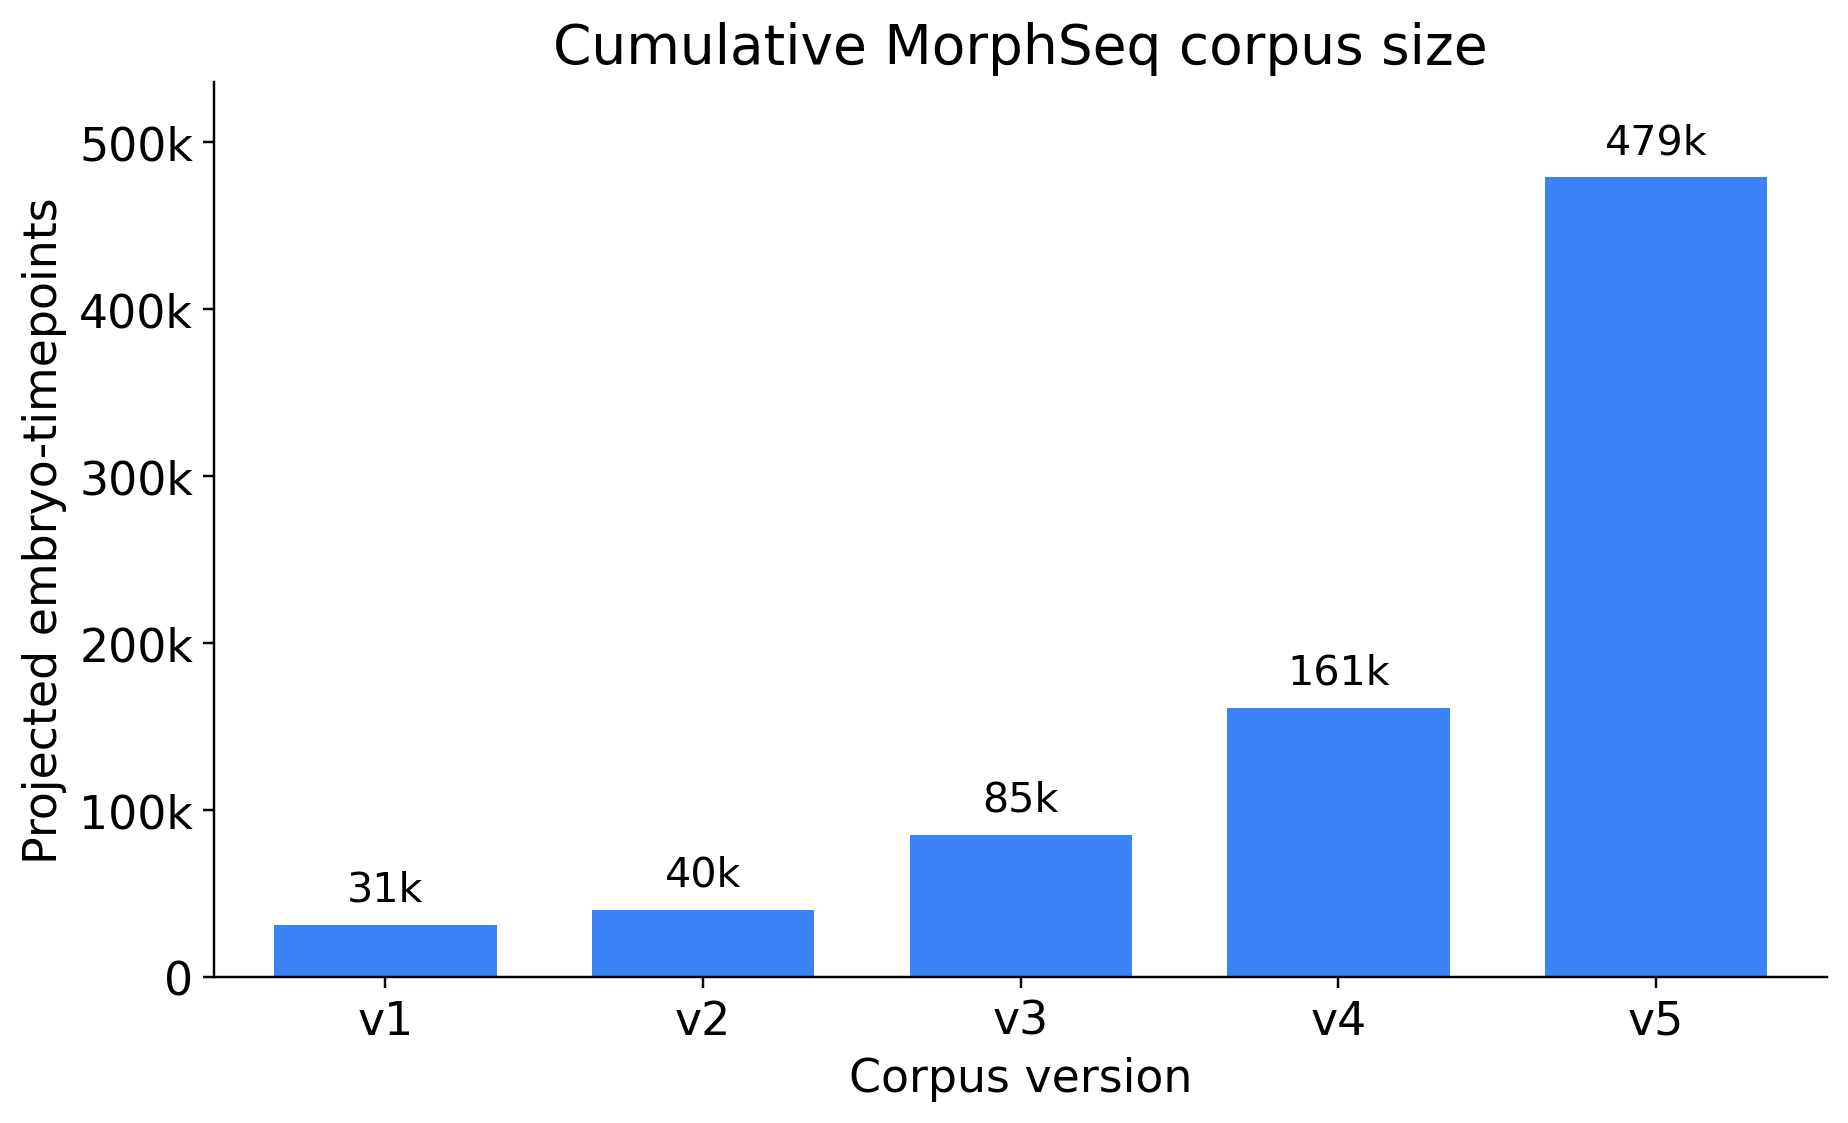

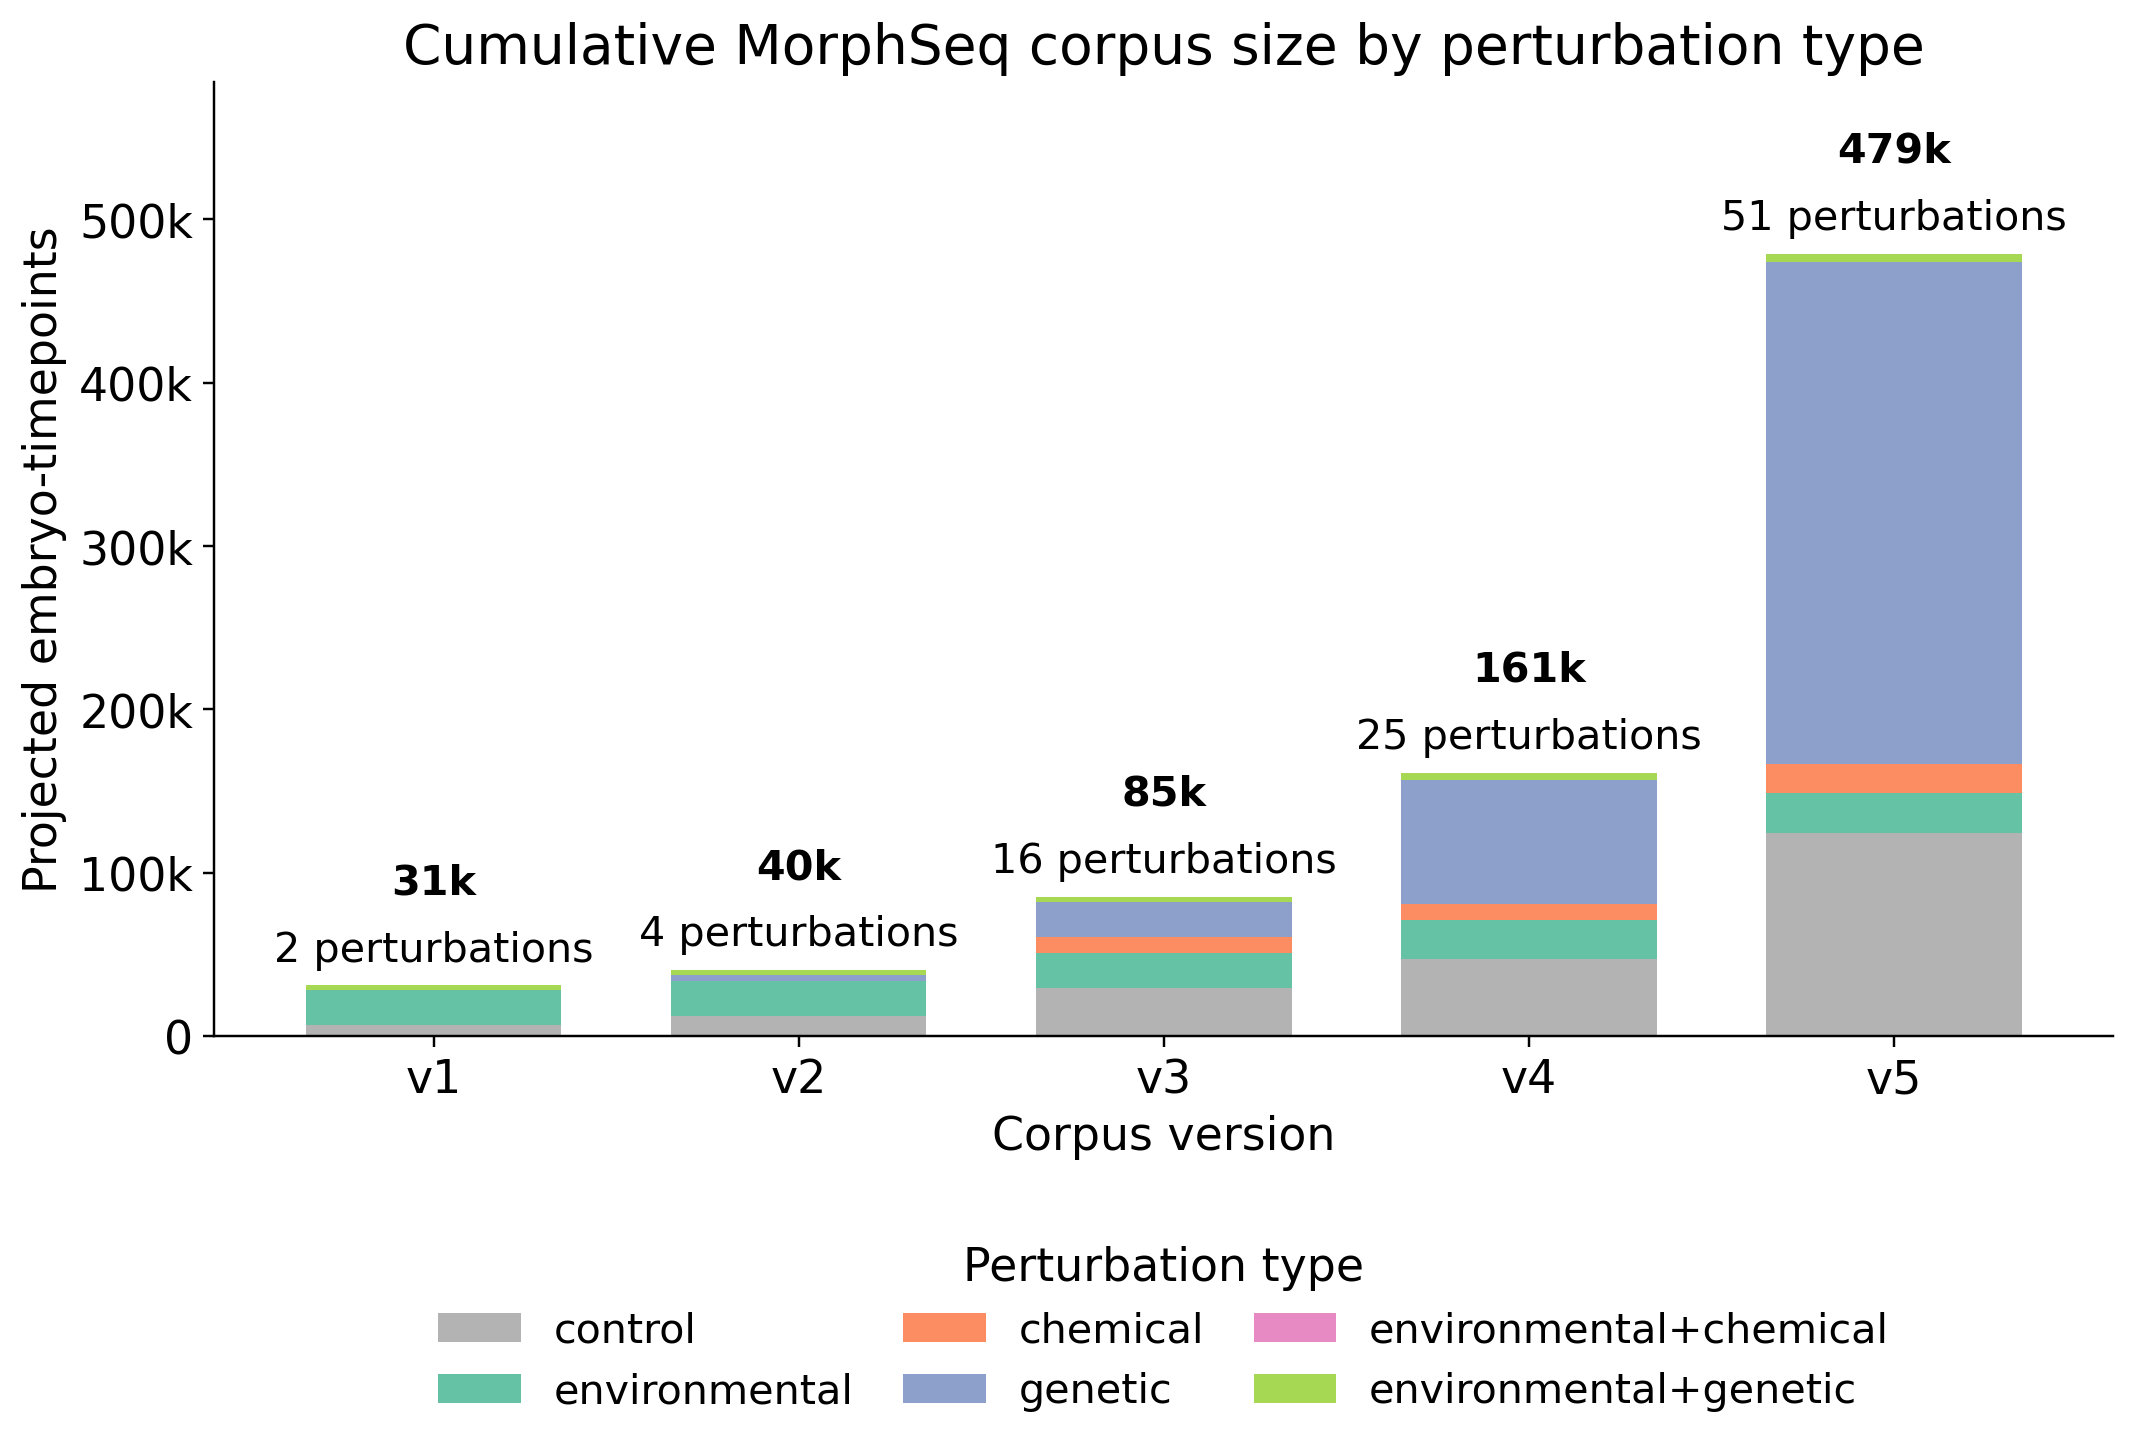

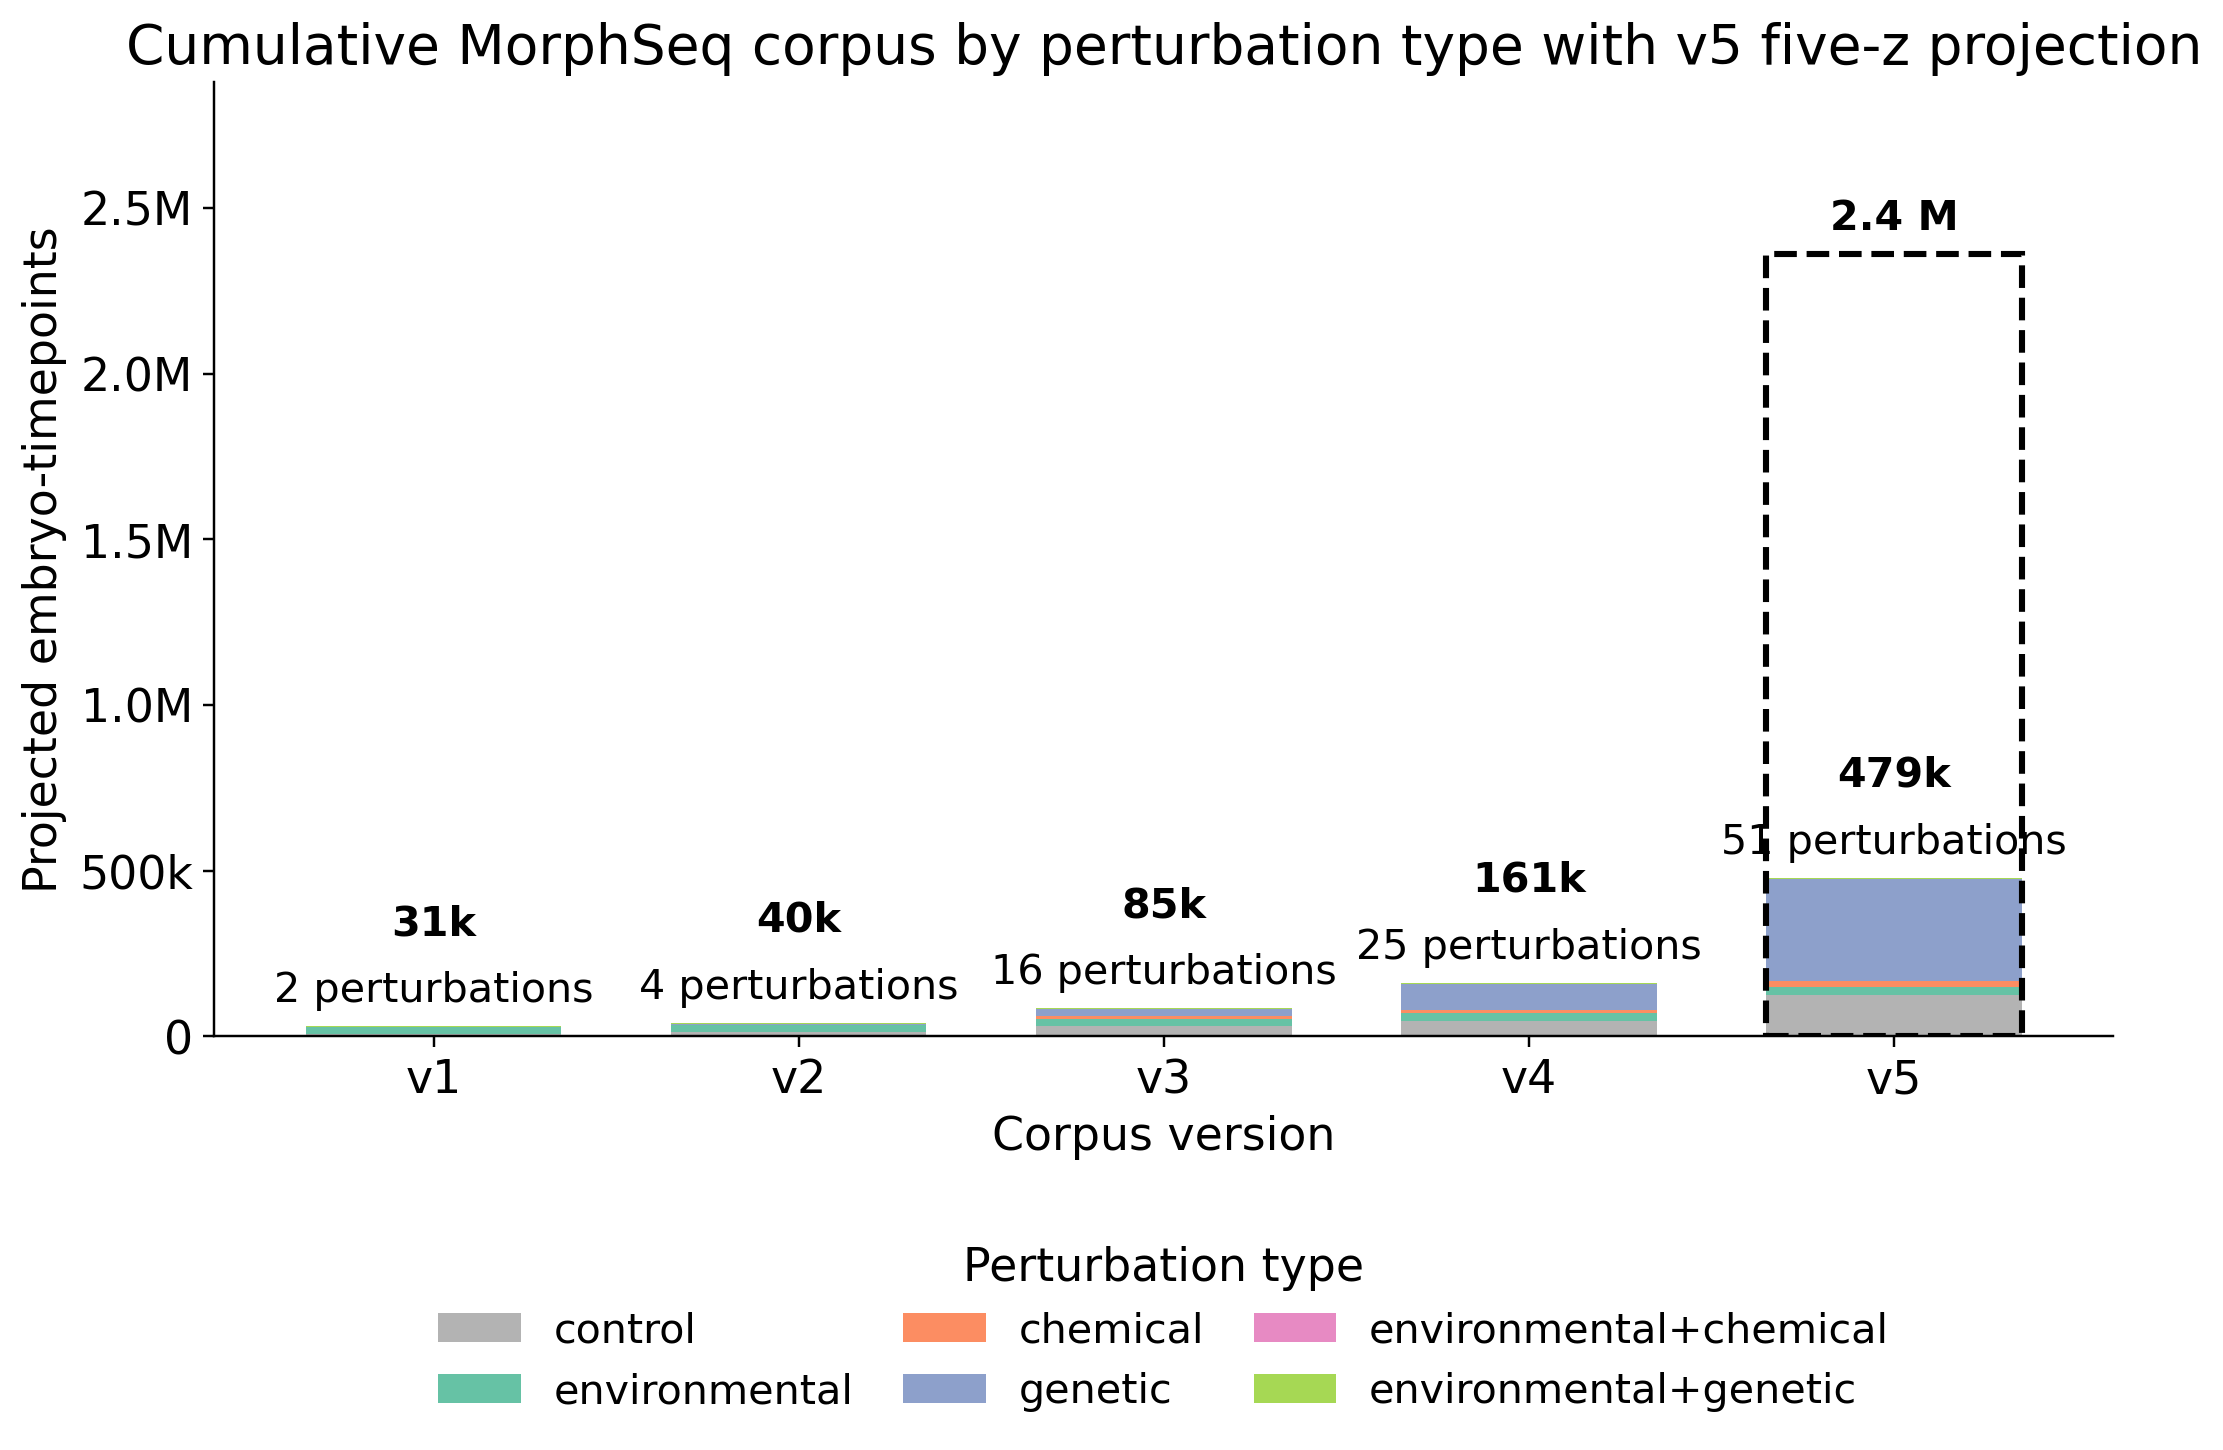

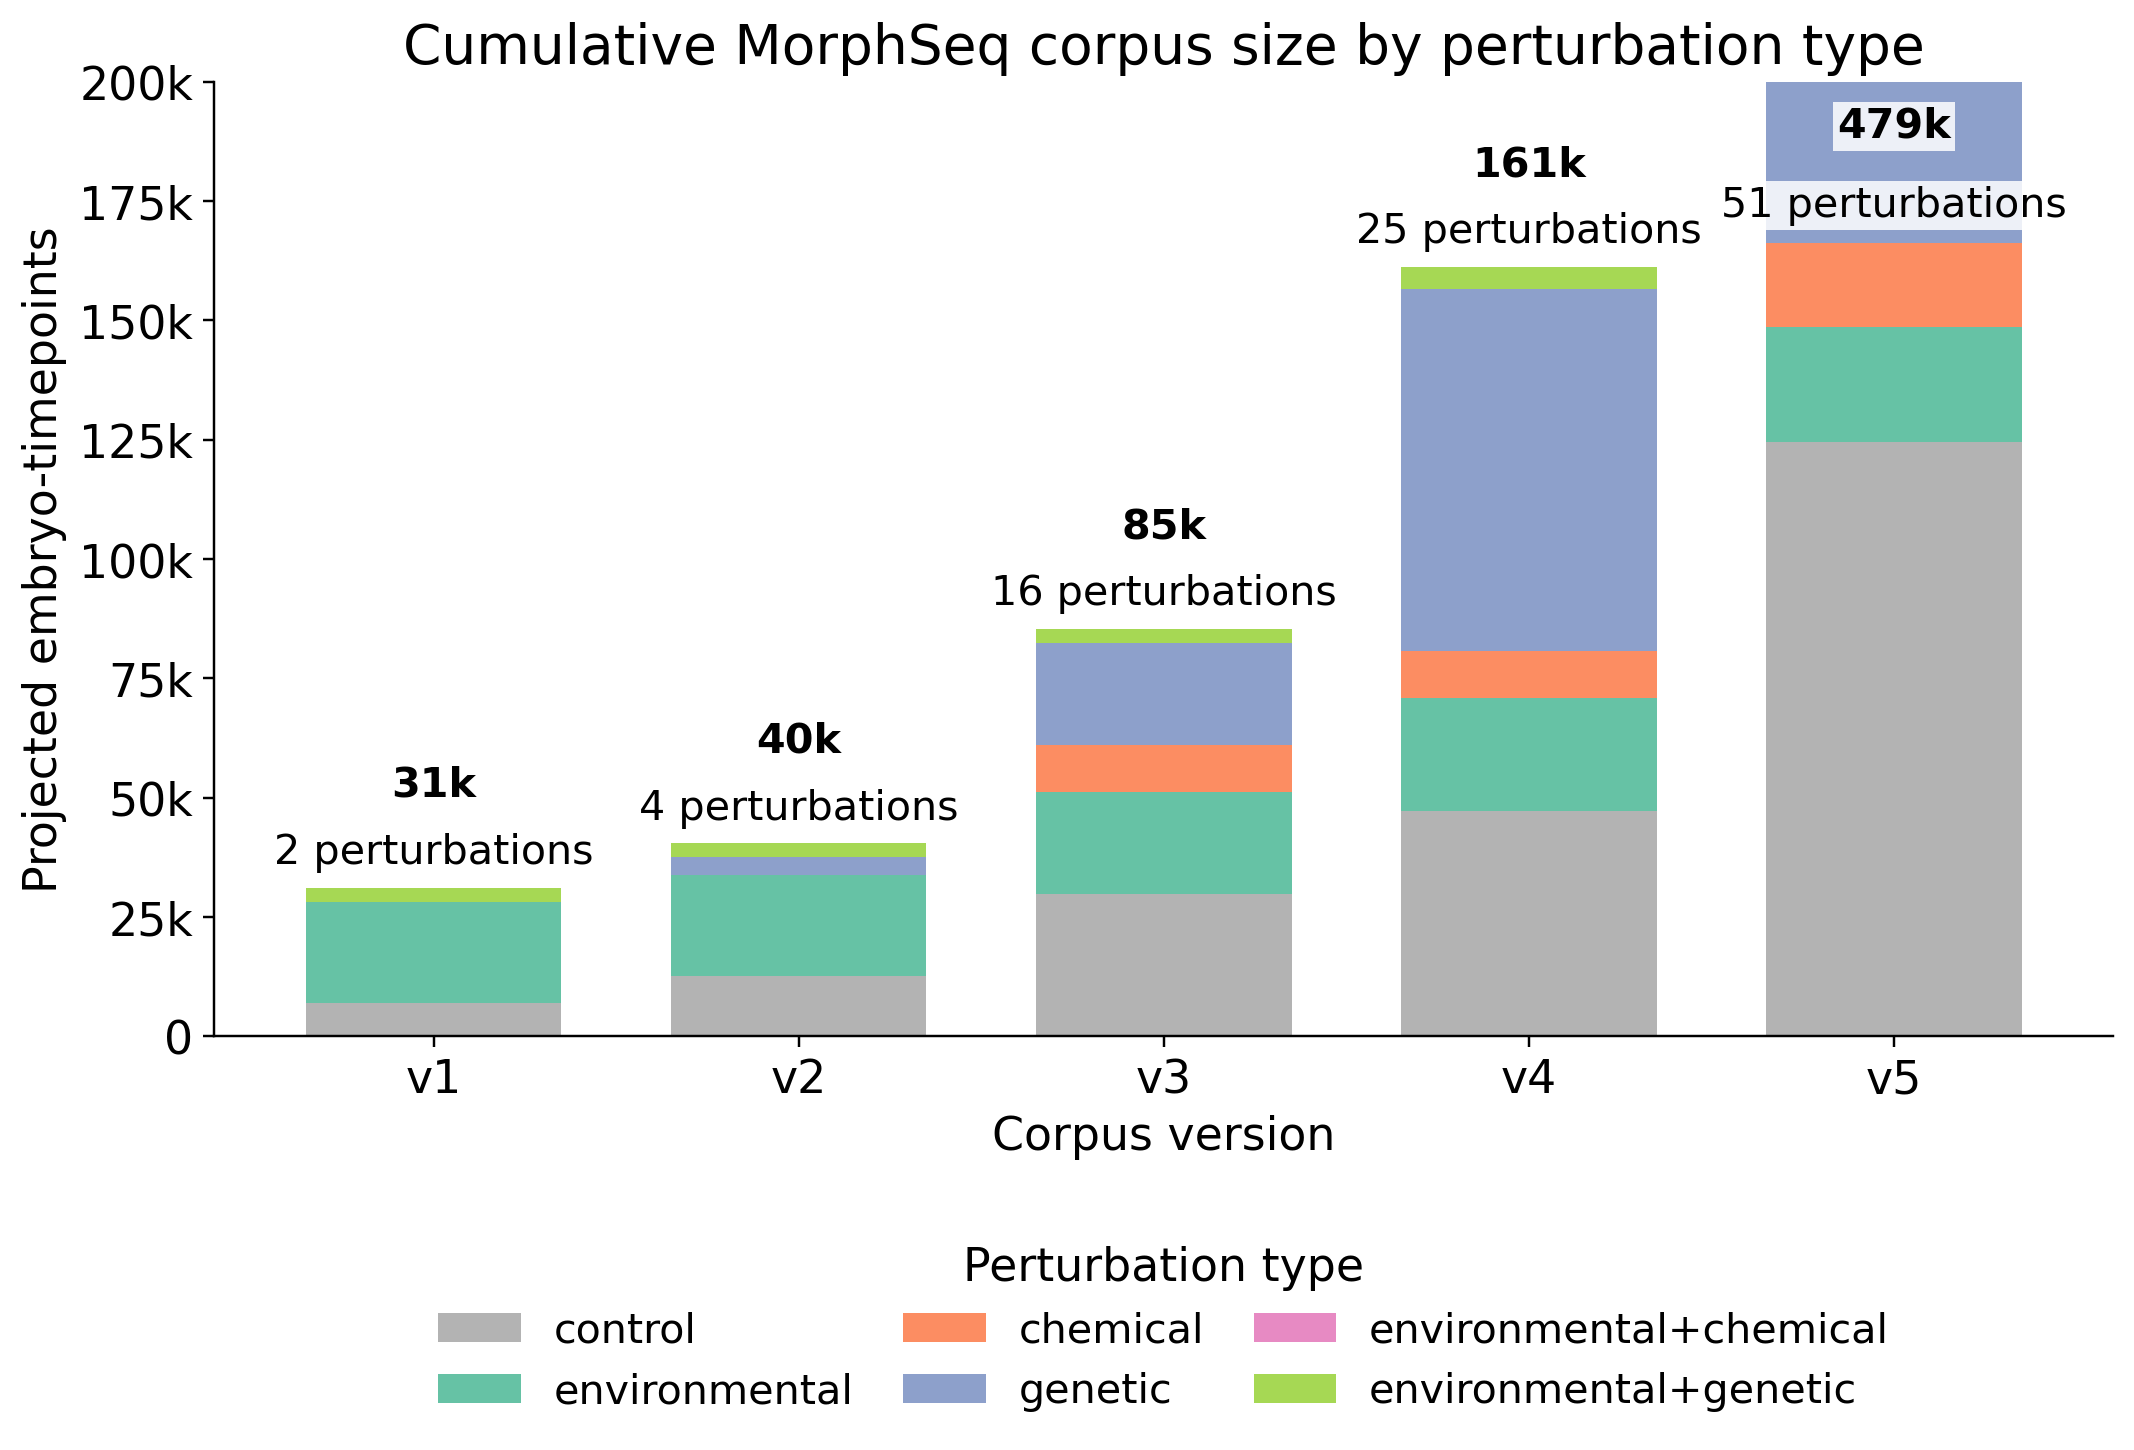

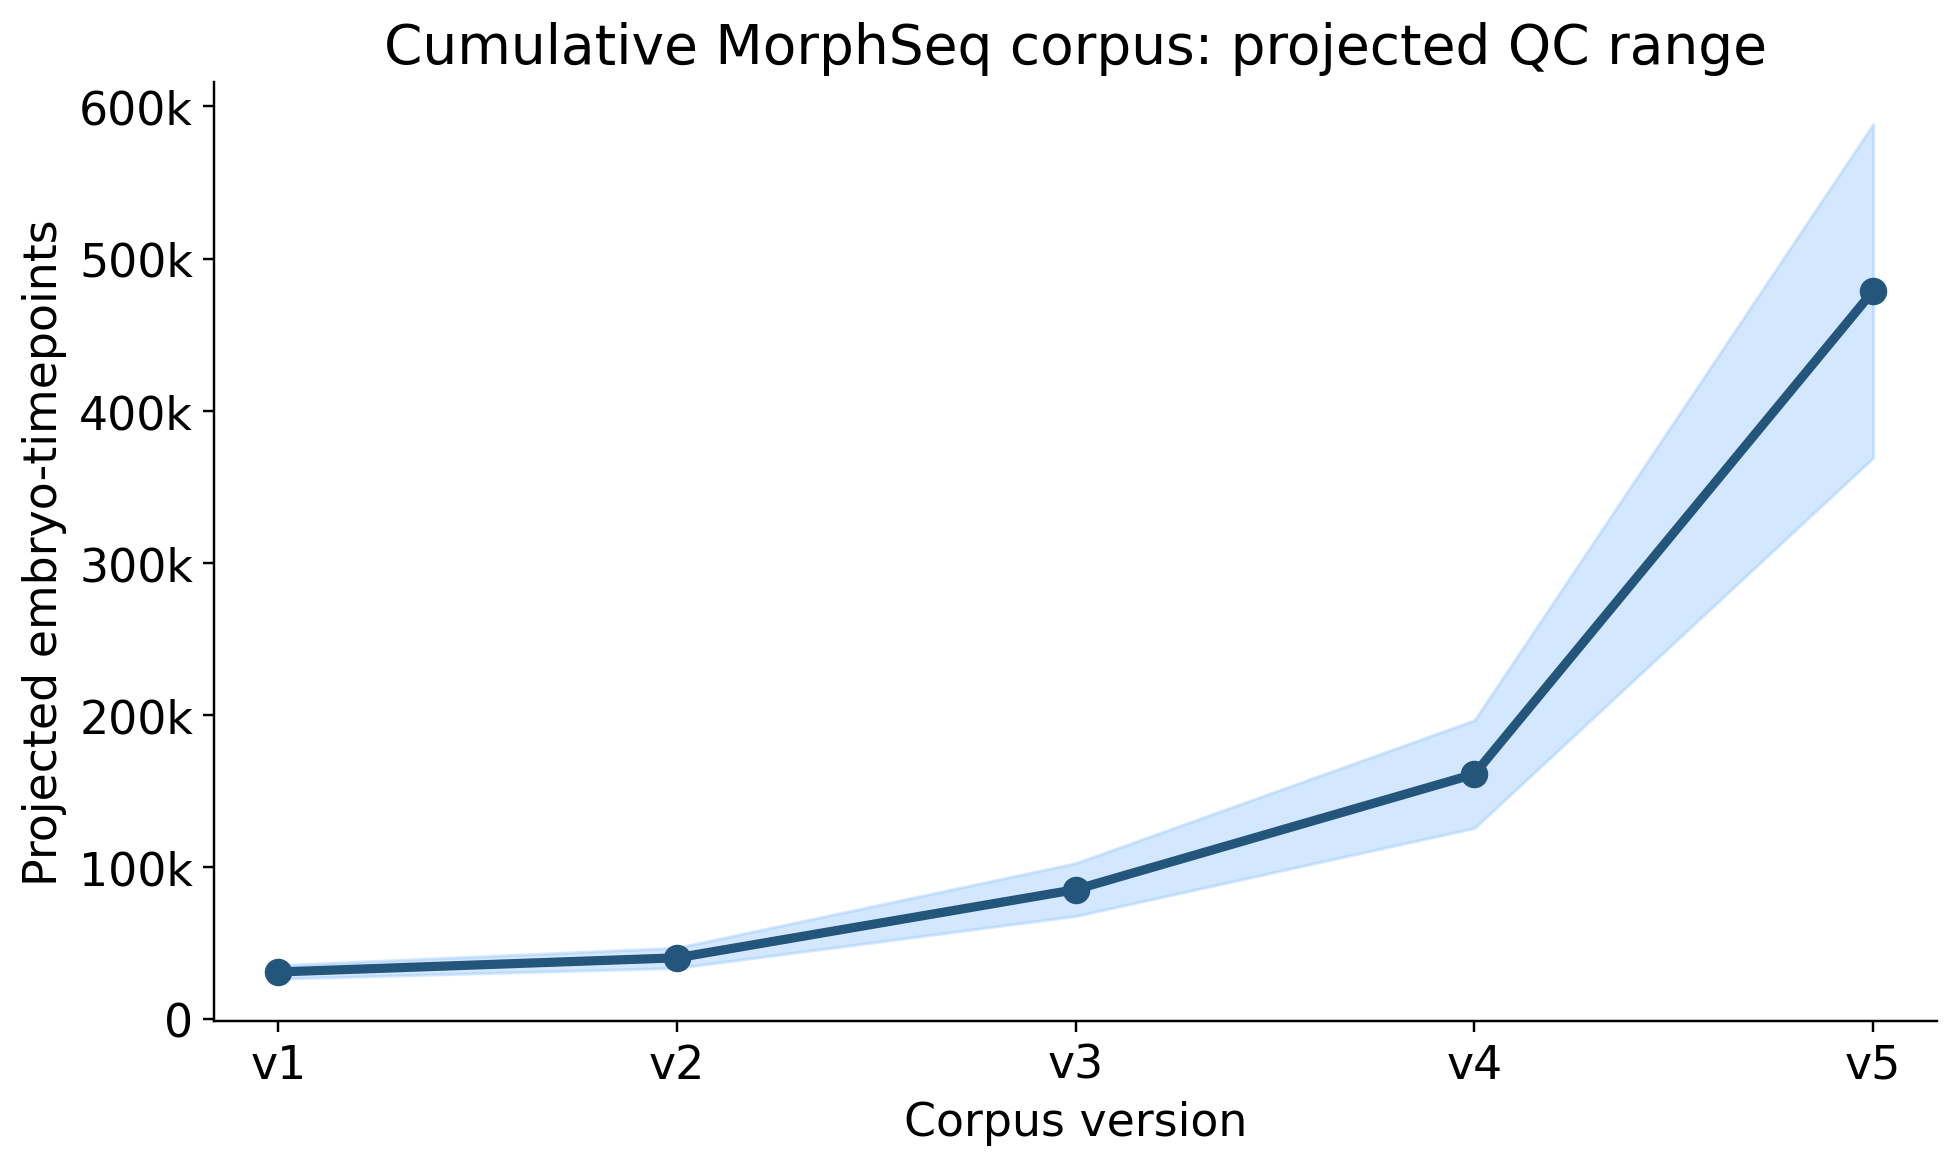

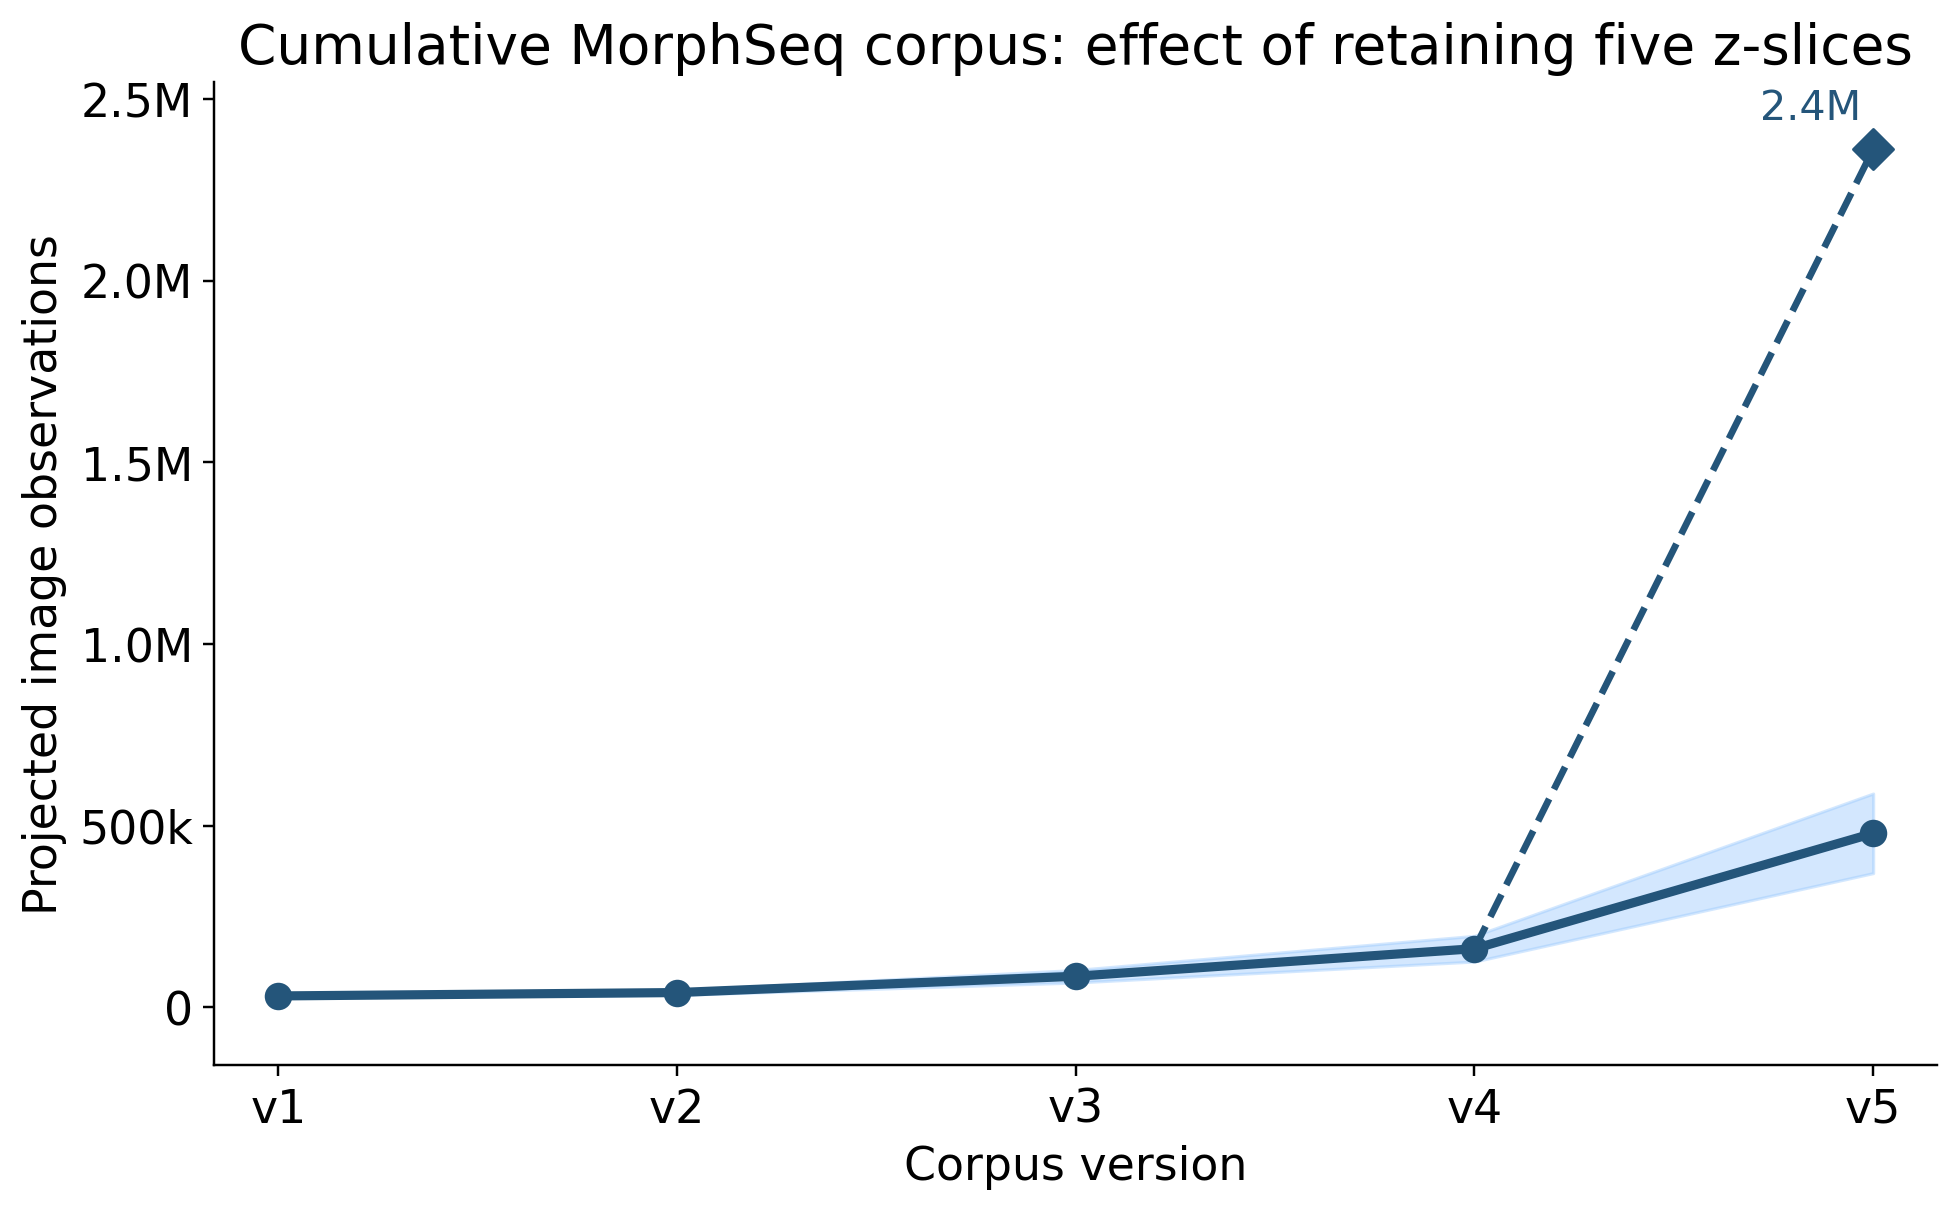

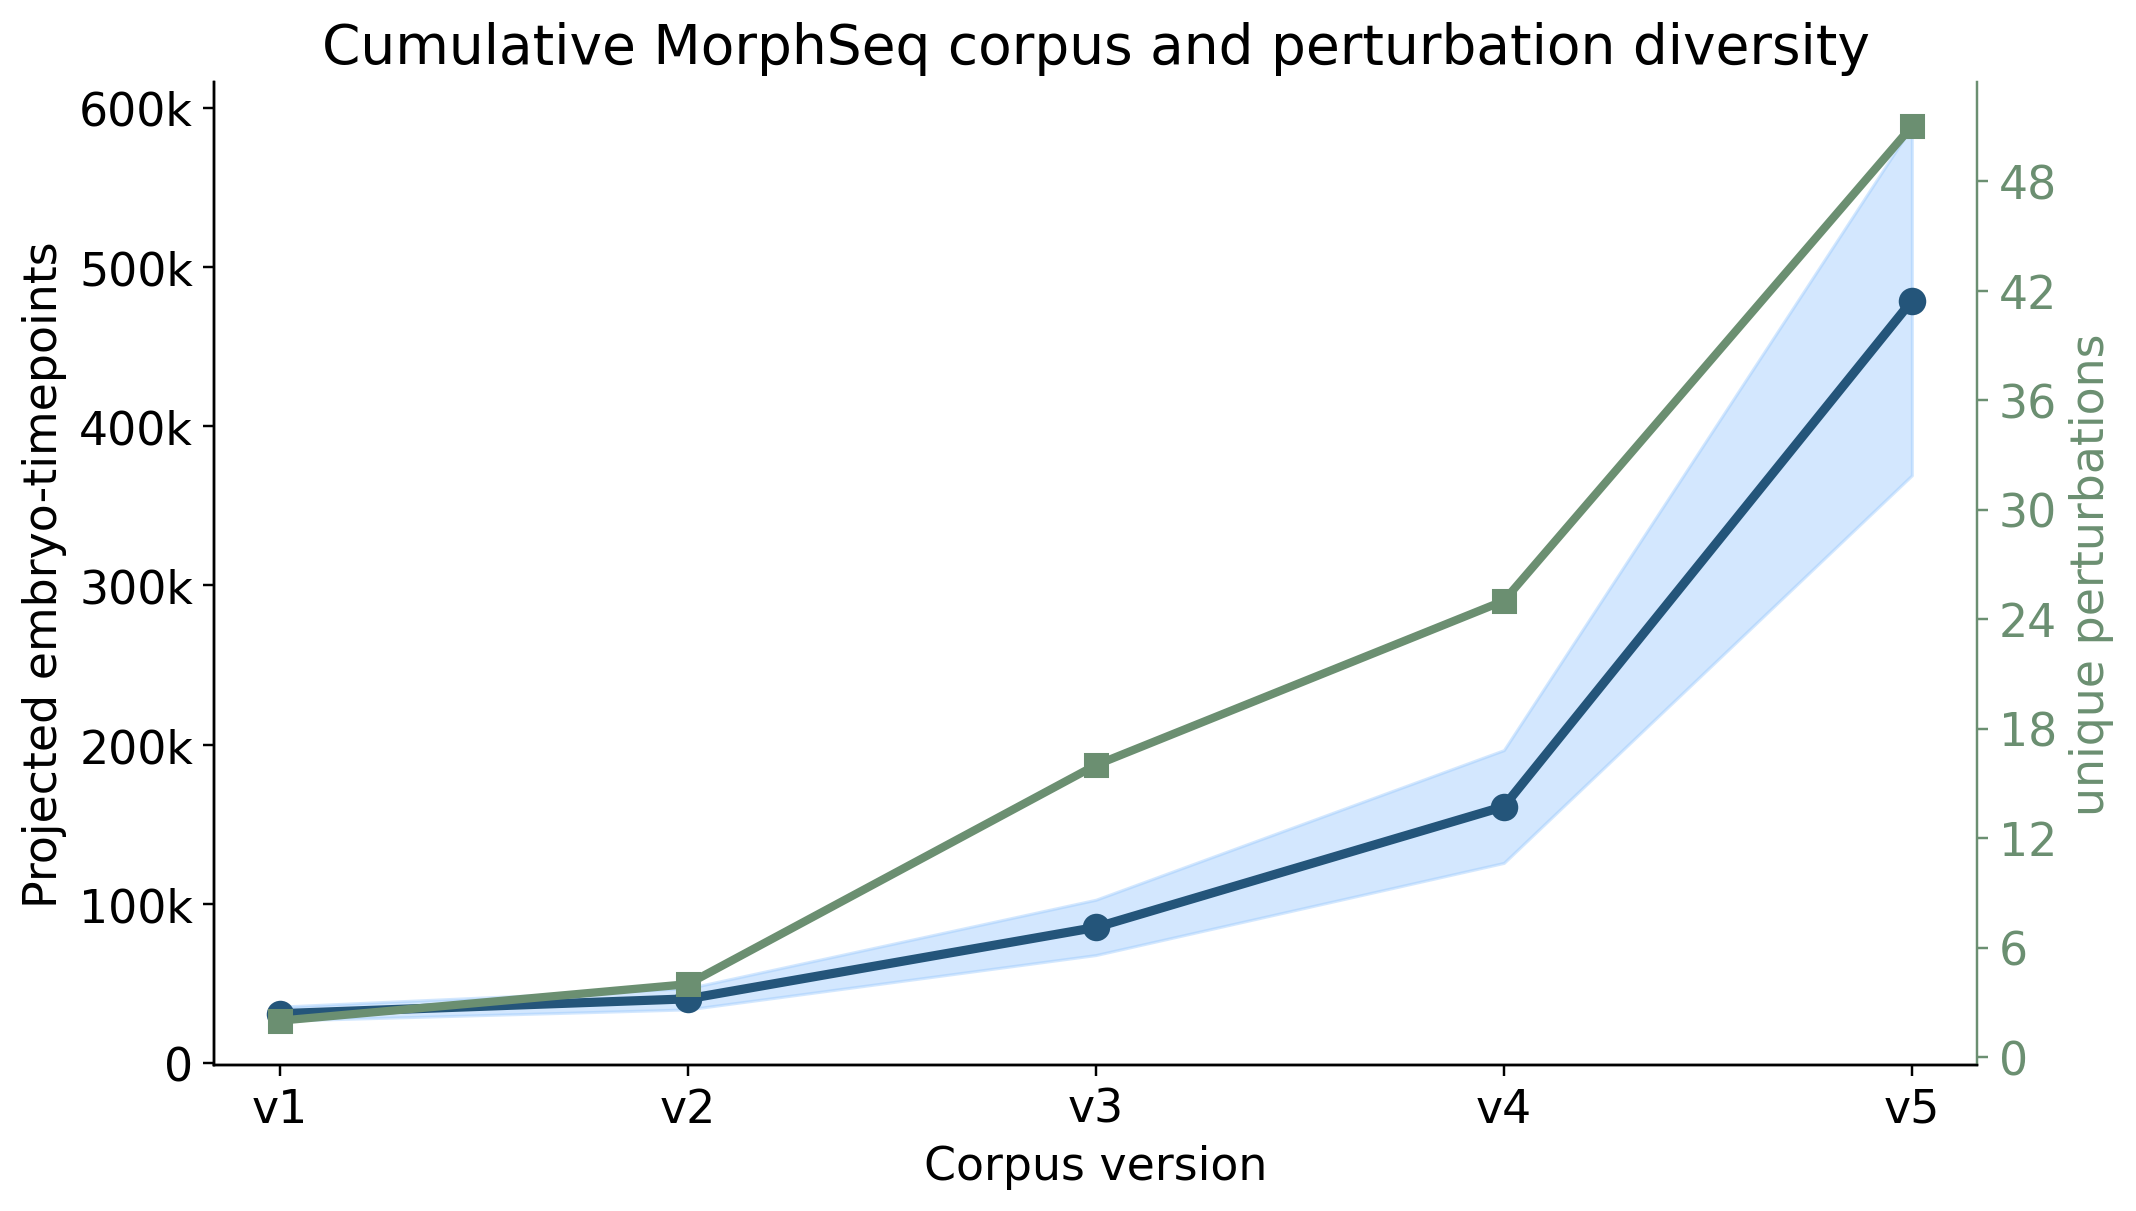

Slide outputs: /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260805/data_census


In [3]:
from plot_training_corpus_versions import (
    REQUESTED_SLIDE_DIR,
    generate_version_figures,
)
from IPython.display import Image

# Plot controls.
COUNT_UNIT = "embryo_times"  # "embryos" or "embryo_times"
Z_SLICE_MULTIPLIER = 5

# The requested laptop path is used when the notebook runs there. Cluster execution falls
# back to a repository-local mirror because /Users/nick is not mounted on the cluster.
SLIDE_OUTPUT_DIR = (
    REQUESTED_SLIDE_DIR
    if REQUESTED_SLIDE_DIR.parent.is_dir()
    else ROOT / "data_census"
)

version_result = generate_version_figures(
    data_dir=DATA,
    output_dir=SLIDE_OUTPUT_DIR,
    count_unit=COUNT_UNIT,
    z_slice_multiplier=Z_SLICE_MULTIPLIER,
)
display(
    version_result["version_estimates"].style.format({
        "gross_count": "{:,.0f}",
        "lower_estimate": "{:,.0f}",
        "midpoint_estimate": "{:,.0f}",
        "upper_estimate": "{:,.0f}",
        "unique_perturbation_count": "{:,.0f}",
        "midpoint_5z_estimate": "{:,.0f}",
    })
)
display(
    version_result["projection_rates"].style.format({
        "lower_timepoint_rate": "{:.1%}",
        "upper_timepoint_rate": "{:.1%}",
        "lower_embryo_rate": "{:.1%}",
        "upper_embryo_rate": "{:.1%}",
    })
)
for figure_path in version_result["figure_paths"]:
    if figure_path.suffix.lower() == ".png":
        display(Image(filename=str(figure_path)))
print(f"Slide outputs: {version_result['output_dir']}")

## Corpus scale by acquisition scope

Solid bars show gross acquisition opportunity; hatched overlays show projected post-QC
availability. Confirmed counts are intentionally shown separately because pipeline completion
is still changing.

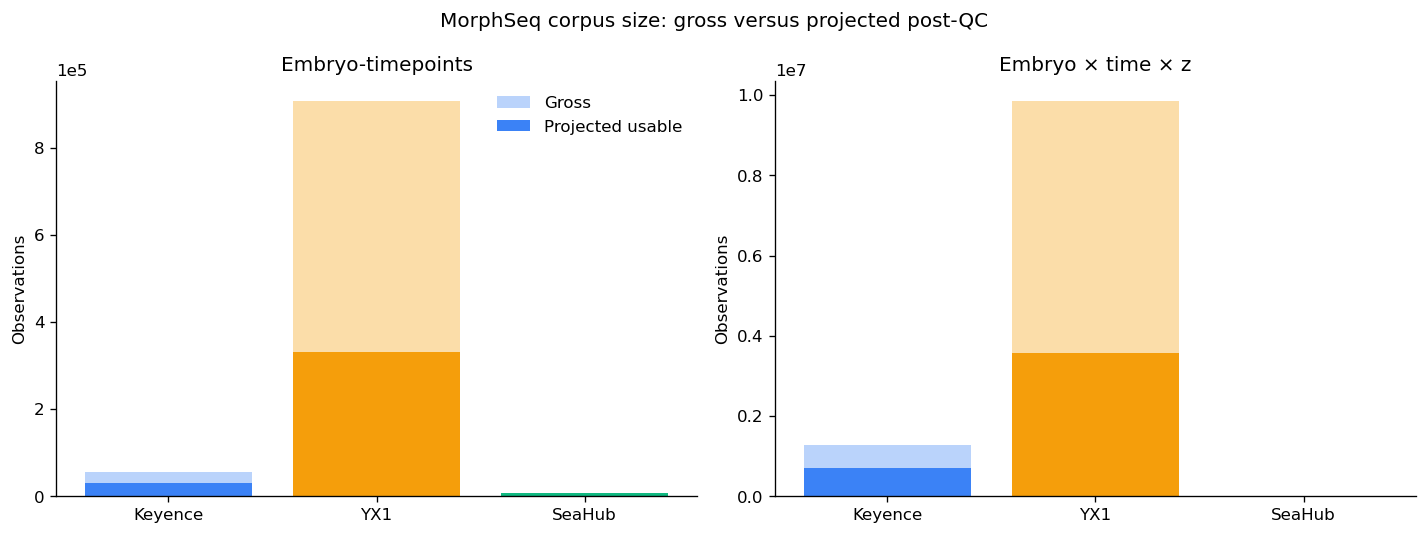

In [4]:
plot = scope[scope.scope.isin(scope_order)].set_index("scope").reindex(scope_order)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, gross_col, projected_col, title in [
    (axes[0], "gross_embryo_timepoints", "projected_usable_timepoints", "Embryo-timepoints"),
    (axes[1], "gross_embryo_z_observations", "projected_usable_z_observations", "Embryo × time × z"),
]:
    x = np.arange(len(plot))
    gross = plot[gross_col].to_numpy()
    projected = plot[projected_col].to_numpy()
    ax.bar(x, gross, color=[colors[s] for s in plot.index], alpha=.35, label="Gross")
    ax.bar(x, projected, color=[colors[s] for s in plot.index], label="Projected usable")
    ax.set_xticks(x, plot.index)
    ax.set_title(title)
    ax.set_ylabel("Observations")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axes[0].legend(frameon=False)
fig.suptitle("MorphSeq corpus size: gross versus projected post-QC")
fig.tight_layout()
fig.savefig(FIGURES / "corpus_size_by_scope.png", bbox_inches="tight")
fig.savefig(FIGURES / "corpus_size_by_scope.pdf", bbox_inches="tight")
plt.show()

## Processing and QC coverage

In [5]:
coverage = (
    datasets.groupby("scope")
    .agg(
        datasets=("corpus_dataset_id", "nunique"),
        gross=("gross_embryo_timepoints", "sum"),
        observed=("observed_valid_snip_timepoints", "sum"),
        qc_evaluated=("qc_evaluated_timepoints", "sum"),
        confirmed_usable=("confirmed_usable_timepoints", "sum"),
    )
    .reindex(scope_order)
)
for col in ["observed", "qc_evaluated", "confirmed_usable"]:
    coverage[col + "_fraction"] = coverage[col] / coverage["gross"].replace(0, np.nan)
display(coverage.style.format("{:,.0f}", subset=["gross", "observed", "qc_evaluated", "confirmed_usable"])
        .format("{:.1%}", subset=["observed_fraction", "qc_evaluated_fraction", "confirmed_usable_fraction"]))

,datasets,gross,observed,qc_evaluated,confirmed_usable,observed_fraction,qc_evaluated_fraction,confirmed_usable_fraction
scope,,,,,,,,
Keyence,97,"55,376","28,842","28,842","15,763",52.1%,52.1%,28.5%
YX1,65,"907,794","763,574","422,276","153,880",84.1%,46.5%,17.0%
SeaHub,20,"8,152",0,0,0,0.0%,0.0%,0.0%


## Perturbation coverage

Conditions retain combinations (for example `environmental+chemical`). The atomic table
explodes combinations into unique temperature, chemical, and genetic targets.

perturbation_domain,chemical,environmental,genetic
scope,,,
Keyence,2,8,10
YX1,5,1,31
SeaHub,18,3,160


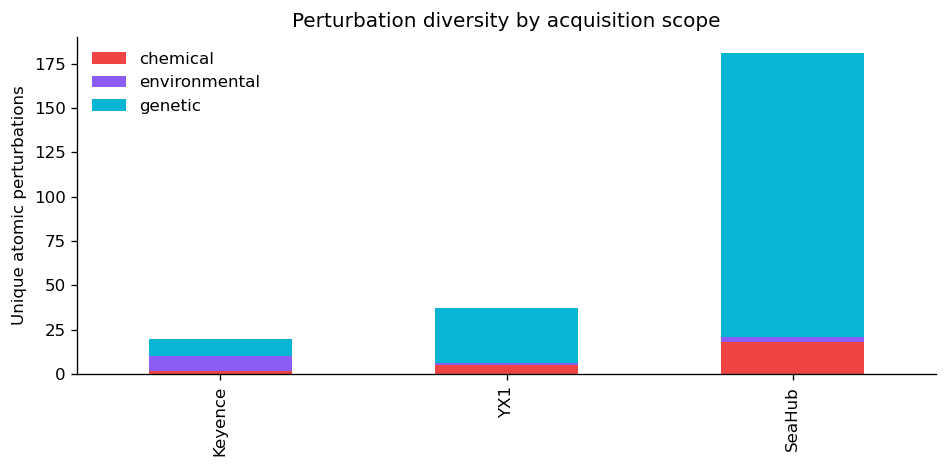

perturbation_class,chemical,control,environmental,environmental+chemical,environmental+genetic,genetic
scope,,,,,,
Keyence,86,"15,048","33,926",358,"4,866","1,092"
YX1,"34,661","237,102","4,680",0,"3,198","628,153"
SeaHub,968,"1,296",272,0,32,"5,584"


In [6]:
unique_atomic = (
    atomic.groupby(["scope", "perturbation_domain"])["atomic_perturbation"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(scope_order)
)
display(unique_atomic)
ax = unique_atomic.plot(kind="bar", stacked=True, figsize=(8, 4),
                        color={"environmental": "#8B5CF6", "chemical": "#EF4444", "genetic": "#06B6D4"})
ax.set_ylabel("Unique atomic perturbations")
ax.set_xlabel("")
ax.set_title("Perturbation diversity by acquisition scope")
ax.legend(title="", frameon=False)
plt.tight_layout()
plt.savefig(FIGURES / "unique_perturbations_by_scope.png", bbox_inches="tight")
plt.savefig(FIGURES / "unique_perturbations_by_scope.pdf", bbox_inches="tight")
plt.show()

condition_volume = (
    wells.groupby(["scope", "perturbation_class"])["gross_embryo_timepoints"]
    .sum().unstack(fill_value=0).reindex(scope_order)
)
display(condition_volume.style.format("{:,.0f}"))

## Sequencing-linked imaging sets

In [7]:
seq_display = sequencing.loc[
    sequencing["pairing_status"].ne("not_linked"),
    [
        "scope", "corpus_dataset_id", "pairing_status",
        "linked_well_or_embryo_count", "total_well_or_embryo_count",
        "collection_name", "sequencing_modality", "sequencing_dataset_id",
        "pairing_granularity", "evidence_source", "curator_notes",
    ],
]
display(seq_display)
print("Edit sequencing_pairing_overrides.csv and refresh to curate Keyence/YX1 links.")

,scope,corpus_dataset_id,pairing_status,linked_well_or_embryo_count,total_well_or_embryo_count,collection_name,sequencing_modality,sequencing_dataset_id,pairing_granularity,evidence_source,curator_notes
0,Keyence,20230525,unknown,0,96,NaN,NaN,NaN,NaN,NaN,NaN
1,Keyence,20230531,unknown,0,96,NaN,NaN,NaN,NaN,NaN,NaN
2,Keyence,20230602,unknown,0,96,NaN,NaN,NaN,NaN,NaN,NaN
3,Keyence,20230608,unknown,0,1,NaN,NaN,NaN,NaN,NaN,NaN
4,Keyence,20230613,unknown,0,96,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
177,YX1,20260415_sci_cep290_48hpf_plate01,unknown,0,96,NaN,NaN,NaN,NaN,NaN,NaN
178,YX1,20260417_irx_pilot,unknown,0,96,NaN,NaN,NaN,NaN,NaN,NaN
179,YX1,20260418_irx_pilot,unknown,0,96,NaN,NaN,NaN,NaN,NaN,NaN
180,YX1,20260501_zfpm_pilot,unknown,0,96,NaN,NaN,NaN,NaN,NaN,NaN


Edit sequencing_pairing_overrides.csv and refresh to curate Keyence/YX1 links.


## Classification review queue

In [8]:
review = (
    wells.loc[wells["classification_needs_review"].astype(bool),
              ["scope", "corpus_dataset_id", "perturbation", "genotype",
               "chem_perturbation", "temperature", "perturbation_class",
               "condition_signature", "classification_review_reason"]]
    .drop_duplicates()
    .sort_values(["scope", "corpus_dataset_id"])
)
print(f"{len(review):,} unique labels/conditions need review")
display(review.head(200))

103 unique labels/conditions need review


,scope,corpus_dataset_id,perturbation,genotype,chem_perturbation,temperature,perturbation_class,condition_signature,classification_review_reason
1160,Keyence,20260324_cep290_18hpf_24hpf_plate02,NaN,cep290_wt,NaN,28.5,control,control,non-empty labels classified as control
1162,Keyence,20260324_cep290_18hpf_24hpf_plate02,NaN,cep290_unknown,NaN,28.5,genetic,G:cep290,unknown genetic status
1163,Keyence,20260324_cep290_18hpf_24hpf_plate02,NaN,uncertain,NaN,28.5,control,control,uncertain genotype label; unknown genetic stat...
1256,Keyence,20260324_cep290_18hpf_plate01,NaN,cep290_wt,NaN,28.5,control,control,non-empty labels classified as control
1264,Keyence,20260324_cep290_18hpf_plate01,NaN,cep290_unknown,NaN,28.5,genetic,G:cep290,unknown genetic status
...,...,...,...,...,...,...,...,...,...
11746,YX1,20260228,NaN,tmem67_wildtype,NaN,30.0,control,control,non-empty labels classified as control
12420,YX1,20260414_sci_b9d2_48hpf_plate01,NaN,b9d2_wt,NaN,30.0,control,control,non-empty labels classified as control
12473,YX1,20260414_sci_b9d2_48hpf_plate01,NaN,b9d2_unknown,NaN,30.0,genetic,G:b9d2,unknown genetic status
12518,YX1,20260415_sci_cep290_48hpf_plate01,NaN,uncertain,NaN,30.0,control,control,uncertain genotype label; unknown genetic stat...


## Detailed dataset census

In [9]:
display(
    datasets.sort_values(["scope", "gross_embryo_timepoints"], ascending=[True, False])
    .style.format({
        "gross_embryo_timepoints": "{:,.0f}",
        "gross_embryo_z_observations": "{:,.0f}",
        "z_expansion_factor": "{:.1f}×",
        "qc_coverage_fraction": "{:.1%}",
        "confirmed_retention_rate": "{:.1%}",
        "projected_usable_timepoints": "{:,.0f}",
    })
)

,scope,corpus_dataset_id,gross_embryos,observed_unique_physical_embryos,gross_embryo_timepoints,gross_embryo_z_observations,observed_snip_timepoints,observed_valid_snip_timepoints,qc_evaluated_timepoints,confirmed_usable_timepoints,projected_usable_timepoints,projected_usable_z_observations,pipeline_experiment_count,well_count,exact_well_count,perturbation_condition_count,stage_min_hpf,stage_max_hpf,frame_inventory_fraction,detected_fraction,sequencing_link_fraction,project_name,z_expansion_factor,qc_coverage_fraction,confirmed_retention_rate
2,Keyence,20230602,114.000000,95,"11,105","266,520",8998,8998,8998,3447,"4,599",110364.897025,1,96,79,1,15.500000,15.500000,0.822917,0.822917,nan,Legacy / unspecified,24.0×,81.0%,38.3%
1,Keyence,20230531,138.000000,124,"9,108","209,484",7846,7846,7846,4044,"4,734",108875.561404,1,96,83,1,15.000000,15.000000,0.864583,0.864583,nan,Legacy / unspecified,23.0×,86.1%,51.5%
4,Keyence,20230613,104.000000,83,"6,837","164,088",5421,5421,5421,3611,"4,385",105237.254005,1,96,75,2,11.660000,11.660000,0.781250,0.781250,nan,Legacy / unspecified,24.0×,79.3%,66.6%
0,Keyence,20230525,96.000000,0,"5,826","151,476",0,0,0,0,"3,184",82786.082380,1,96,83,1,15.000000,15.000000,0.864583,0.000000,nan,Legacy / unspecified,26.0×,0.0%,nan%
5,Keyence,20230615,102.000000,85,"5,100","122,400",4216,4216,4216,2767,"3,250",78003.167048,1,96,79,1,10.000000,10.000000,0.822917,0.822917,nan,Legacy / unspecified,24.0×,82.7%,65.6%
8,Keyence,20230627,73.000000,0,"3,285","95,265",0,0,0,0,"1,795",52065.120137,1,73,73,1,nan,nan,1.000000,0.000000,nan,Legacy / unspecified,29.0×,0.0%,nan%
6,Keyence,20230620,32.000000,0,"2,835","68,040",0,0,0,0,"1,549",37185.858124,1,32,32,1,nan,nan,1.000000,0.000000,nan,Legacy / unspecified,24.0×,0.0%,nan%
9,Keyence,20230629,67.000000,0,"2,757","71,682",0,0,0,0,"1,507",39176.318078,1,67,67,1,nan,nan,1.000000,0.000000,nan,Legacy / unspecified,26.0×,0.0%,nan%
7,Keyence,20230622,46.000000,0,"1,987","47,688",0,0,0,0,"1,086",26062.892449,1,46,46,1,nan,nan,1.000000,0.000000,nan,Legacy / unspecified,24.0×,0.0%,nan%
93,Keyence,20260702_hotchem_30hpf_plate01,125.000000,124,125,"1,750",124,124,124,79,80,1113.651411,1,96,96,9,30.843333,31.383333,1.000000,0.989583,nan,Chemical perturbation,14.0×,99.2%,63.7%


## Important limitations

- Gross Keyence/YX1 counts use metadata `embryos_per_well`; where a frame inventory is
  missing, within-dataset median time/z depth is used and flagged.
- Where `embryos_per_well` is absent or too small, the peak number of concurrently detected
  embryos in that well supplies a conservative lower-bound embryo count. This avoids
  undercounting multi-embryo YX1 wells but can inherit detection errors.
- Projection rates describe the datasets that have completed QC; they may not represent
  the hardest unfinished datasets.
- SeaHub currently has detection-completion retention only, not completed downstream QC.
- “Sequencing linked” indicates a collection/condition link, not necessarily the identical
  individual embryo.
- Perturbation classes are rule-based. Review the generated classification queue before
  using exact diversity counts in a talk.